In [15]:
from IPython.display import HTML
from plots.utils import gate_probs_html, get_character_list

In [16]:
# Helper function: plot where the model puts high probability gates.
def plot_gate_probs(raw_html):
    return display(HTML(raw_html))

In [17]:
from clean_code.flexible_bitter_llm import FlexibleBitterLLM, LinearGater, text_to_tensor, per_token_losses_backbone, DownsampleRateEmbedding
from clean_code.conditional_sequential import OptimizedSequentialyDependentLinearGater, ScaledSequentialyDependentLinearGater
from clean_code.nawrot_plugin import NawrotDownsampler, NawrotUpsampler, NawrotGater
from accelerate import Accelerator
from training_random_base_model.hparam_utils import get_model_kwargs
from transformers import AutoTokenizer
import torch
from torch.utils.data import DataLoader
from data_processing import split_fineweb


In [18]:
import os
# os.listdir("/scratch/sdauncey/tokenizer_training/training_random_base_model/checkpoints")

In [19]:
_, _, test_set = split_fineweb.get_splits()


Loading dataset from disk:   0%|          | 0/549 [00:00<?, ?it/s]

In [20]:
from clean_code.utils import parameter_count_string

In [21]:
sequentially_dependent_gater_runs = [
    # ScaledSequentialyDependentLinearGater Runs:
    "18M_2025.09.29_03.44",
    "32M_2025.09.28_23.19",
    "73M_2025.10.06_08.08",
    "130M_2025.10.05_02.16",
    "130M_2025.10.27_05.51_underbaked"
    # Non-deviation runs:
    "18M_2025.10.28_19.02",
    "32M_2025.10.28_19.02",
    "73M_2025.10.27_05.53",
    "130M_2025.10.31_06.36"
]

sparse_runs = [
    "73M_2025.10.13_19.05" # 1/12
    "73M_2025.10.13_08.49" # 1/8
    "73M_2025.10.15_18.11" # 1/6
    "73M_2025.10.16_07.21" # 1/2
    "73M_2025.10.17_03.33_underbaked" # 2/3
]

distribute_add_runs = [
    # Upsampler 2: 
    "18M__2025.11.04_08.01",
    "18M_43_2025.11.04_08.01",
    "18M_44_2025.11.04_12.51",
    "18M_45_2025.11.04_12.56",
    "18M_46_2025.11.04_17.44",
]

flexi_runs = [
    "flexify_training/checkpoints/32M_2025.10.19_02.42", 
    "flexify_training/checkpoints/73M_2025.10.19_02.42",
    "flexify_training/checkpoints/73M_2025.10.20_04.01"
]

In [24]:
byte_tokenizer = AutoTokenizer.from_pretrained("evabyte/EvaByte", trust_remote_code=True)

#  learned_checkpoint_path = "/scratch/sdauncey/tokenizer_training/training_random_base_model/checkpoints/73M"
run_id = "147M_nawrot___2025.11.19_15.28"
learned_checkpoint_path = f"training_random_base_model/checkpoints/{run_id}"; flexi = False

# learned_checkpoint_path = "training_random_base_model/checkpoints/130M_2025.10.05_02.16"; flexi = False
# learned_checkpoint_path = "flexify_training/checkpoints/73M_2025.10.20_04.01"; model_size="73M"; flexi = True


learned_model_kwargs = get_model_kwargs("147M")
learned_model_kwargs["GaterClass"] = NawrotGater
learned_model_kwargs["DownSamplerClass"] = NawrotDownsampler
learned_model_kwargs["UpsamplerClass"] = NawrotUpsampler



# learned_model_kwargs["vocab_size"] = len(byte_tokenizer) 
# learned_model_kwargs["GaterClass"] = ScaledSequentialyDependentLinearGater
# learned_model_kwargs["gater_kwargs"] = {'scale_factor': 1/16., 'filter_size': 8}

# learned_model_kwargs["n_up_layers"] = 4
# learned_model_kwargs["n_down_layers"] = 4
# learned_model_kwargs["n_mid_layers"] = 6

if flexi:
    learned_model_kwargs["DownsampleRateEmbeddingClass"] = DownsampleRateEmbedding


device = torch.device("cuda")


learned_model = FlexibleBitterLLM(**learned_model_kwargs).to(device, dtype=torch.bfloat16)

accelerator = Accelerator()
learned_model = accelerator.prepare(learned_model)
accelerator.load_state(learned_checkpoint_path)
parameter_count_string(learned_model)


using self._attn_implementation='flash_attention_2'


'147.7M'

In [25]:
from clean_code.conditional_sequential import ScaledSequentialyDependentLinearGater
from optimizing_code.triton_scan_simple import torch_scan_simple, compute_probs, torch_scan_simple_scaled, compute_probs_scaled
import math
from torch import nn

class PatchedScaledSequentialyDependentLinearGater(ScaledSequentialyDependentLinearGater):
    def __init__(self, embedding_dim: int, downsample_rate: float, filter_size: int = 4):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.downsample_rate = downsample_rate
        self.filter_size = filter_size
        self.filter_layer = nn.Linear(embedding_dim, filter_size)


    def forward(self, x: torch.Tensor, downsample_rate: float) -> torch.Tensor:
        
        if downsample_rate is None:
            downsample_rate = self.downsample_rate

        bias = math.log(downsample_rate / (1 - downsample_rate))
        scale = self.scale_factor

        x_init_dtype = x.dtype
        x = x.to(dtype=torch.float32)

        if self.filter_layer.weight.dtype != torch.float32:
            self.to(dtype=torch.float32)
        
        V = self.filter_layer(x)
        filter_flattened = V.flatten(end_dim=1).detach().to(device="cpu", dtype=torch.float32)
        print(f"{bias=}")
        filter_averages = filter_flattened.mean(dim=0)
        filter_stds = filter_flattened.std(dim=0)
        filter_sters = filter_stds / math.sqrt(filter_flattened.shape[0])
        filter_sters = filter_sters.numpy()
        filter_averages = filter_averages.numpy()
        for stder, averge in zip(filter_sters, filter_averages):
            print(f"{averge:.2f} +- {stder:.2f}, ", end="")
        print()
        scan_logits, scan_probs, a = torch_scan_simple_scaled(V, scale_factor=scale, bias=bias)
        logits, probs = compute_probs_scaled(a, V, scale_factor=scale, bias=bias)

        print(f"scan_logits: {scan_logits.device} scan_probs: {scan_probs.device} a: {a.device}")
        print(f"logits: {logits.device} probs: {probs.device} a: {a.device}")

        logit_diffs = logits - scan_logits.to(device=logits.device)
        prob_diffs = probs - scan_probs.to(device=probs.device)
        print(f"{logit_diffs.max().item():.2f} {logit_diffs.min().item():.2f} {logit_diffs.mean().item():.2f}")
        print(f"{prob_diffs.max().item():.2f} {prob_diffs.min().item():.2f} {prob_diffs.mean().item():.2f}")

        print(f"logits: {logits.dtype} probs: {probs.dtype} a: {a.dtype}")
        # logits = logits.to(dtype=torch.bfloat16)
        # probs = probs.to(dtype=torch.bfloat16)
        # a = a.to(dtype=torch.bfloat16)

        logits = logits.to(dtype=x_init_dtype)
        probs = probs.to(dtype=x_init_dtype)
        a = a.to(dtype=x_init_dtype)
        return logits.unsqueeze(-1), probs.unsqueeze(-1), a.unsqueeze(-1)


In [26]:
len(test_set)

32768

In [27]:
# We use: 1, 3, 5, 7 in the paper
data_index = 3
tokens, _ = text_to_tensor(test_set[data_index], byte_tokenizer, 4096, "cuda")
tokens

tensor([[  1, 129, 176,  ..., 165, 172, 175]], device='cuda:0')

In [28]:
token_list = get_character_list(byte_tokenizer, tokens[0])

In [31]:
out = learned_model(tokens)
html_code = gate_probs_html(token_list, out["down_gate_probs"][0])
plot_gate_probs(html_code)

In [14]:
render_dir = f"training_random_base_model/renders/{run_id}"
if not os.path.exists(render_dir):
    os.makedirs(render_dir)
    
with open(f"{render_dir}/heatmaps_{data_index}.html", "w") as f:
    f.write(html_code)

In [ ]:
dgp =  out["down_gate_probs"]
dgl = out["down_gate_logits"]

print(f"mean: {dgp[:, 1:-1].mean().item()} min: {dgp[:, 1:-1].min().item()} max: {dgp[:, 1:-1].max().item()}")
print(f"mean: {dgl[:, 1:-1].mean().item()} min: {dgl[:, 1:-1].min().item()} max: {dgl[:, 1:-1].max().item()}")

mean: 0.1953125 min: 6.198883056640625e-05 max: 0.9921875
mean: -3.171875 min: -9.6875 max: 4.84375


In [ ]:
dgl

tensor([[100.0000,  -0.1650,  -4.9062,  ...,  -3.7500,  -4.7500, 100.0000]],
       device='cuda:0', dtype=torch.bfloat16, grad_fn=<SqueezeBackward1>)

In [ ]:
(dgp == dgp[:, 1:-1].max()).sum()

tensor(50, device='cuda:0')

In [ ]:
my_l = torch.tensor(-0.34765625, dtype=torch.bfloat16)
my_l.sigmoid().item()

0.4140625

In [ ]:
dgp_numpy = dgp.to(device="cpu", dtype=torch.float32).detach().numpy()[0]
dgl_numpy = dgl.to(device="cpu", dtype=torch.float32).detach().numpy()[0, 1:-1]

In [ ]:
0.1357421875 * 2**10

139.0

In [ ]:
from clean_code.flexible_bitter_llm import per_token_losses_backbone

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
loss_mask = torch.ones_like(tokens, dtype=torch.float32)
per_token_losses = per_token_losses_backbone(tokens, loss_mask, out, out["down_gate_probs"], discount_rate=0.9, learn_gating=True, early_exit_advantage_estimate=True)
per_token_losses["selected_action_cross_entropy"]

tensor([[-0.0000, 0.0114, 0.0065,  ..., 0.0026, 0.0027, -0.0000]],
       device='cuda:0', dtype=torch.bfloat16, grad_fn=<ViewBackward0>)

In [ ]:
per_token_losses["selected_action_likelihood_ratios"].max()

tensor(1., device='cuda:0')

(array([2.637e+03, 1.320e+02, 3.900e+01, 2.500e+01, 1.500e+01, 1.100e+01,
        4.000e+00, 5.000e+00, 2.000e+00, 5.000e+00, 1.000e+00, 2.000e+00,
        5.000e+00, 0.000e+00, 0.000e+00, 2.000e+00, 3.000e+00, 0.000e+00,
        2.000e+00, 0.000e+00, 4.000e+00, 1.000e+00, 0.000e+00, 1.000e+00,
        1.000e+00, 2.000e+00, 1.000e+00, 2.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 1.000e+00,
        0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 2.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 4.000e+00, 0.000e+00, 3.000e+00,
        4.000e+00, 0.000e+00, 2.000e+00, 1.000e+00, 0.000e+00, 2.000e+00,
        2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        2.000e+00, 0.000e+00, 3.000e+00, 0.000e+00, 0.000e+00, 2.000e+00,
        2.000e+00, 2.000e+00, 0.000e+00, 1.000e+00, 3.000e+00, 2.000e+00,
        3.000e+00, 3.000e+00, 1.000e+00, 1.000e+00, 3.000e+00, 1.000e+00,
        7.000e+00, 3.000e+00, 4.000e+0

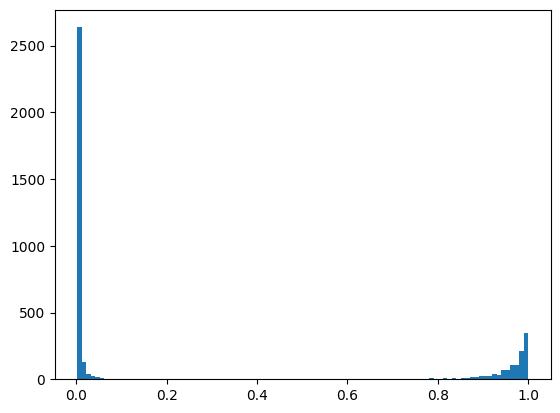

In [ ]:
plt.hist(dgp_numpy, bins=100)

(array([1.019e+03, 4.830e+02, 2.660e+02, 1.850e+02, 1.200e+02, 7.700e+01,
        8.600e+01, 7.200e+01, 6.200e+01, 8.500e+01, 6.900e+01, 4.100e+01,
        4.600e+01, 3.300e+01, 3.900e+01, 3.500e+01, 1.900e+01, 1.200e+01,
        2.500e+01, 1.500e+01, 7.000e+00, 1.500e+01, 1.200e+01, 9.000e+00,
        9.000e+00, 6.000e+00, 9.000e+00, 4.000e+00, 4.000e+00, 4.000e+00,
        2.000e+00, 5.000e+00, 1.000e+00, 3.000e+00, 4.000e+00, 0.000e+00,
        4.000e+00, 2.000e+00, 3.000e+00, 3.000e+00, 2.000e+00, 3.000e+00,
        2.000e+00, 2.000e+00, 2.000e+00, 2.000e+00, 1.000e+00, 2.000e+00,
        4.000e+00, 7.000e+00, 3.000e+00, 4.000e+00, 0.000e+00, 2.000e+00,
        4.000e+00, 3.000e+00, 3.000e+00, 5.000e+00, 7.000e+00, 2.000e+00,
        4.000e+00, 1.100e+01, 9.000e+00, 1.300e+01, 9.000e+00, 1.500e+01,
        1.500e+01, 2.400e+01, 2.800e+01, 1.800e+01, 3.200e+01, 2.200e+01,
        2.800e+01, 2.800e+01, 4.200e+01, 4.100e+01, 4.400e+01, 3.100e+01,
        3.400e+01, 5.100e+01, 3.300e+0

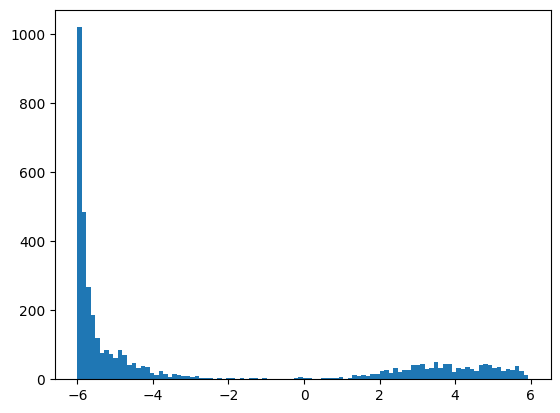

In [ ]:
plt.hist(dgl_numpy, bins=100)